### Middleware

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

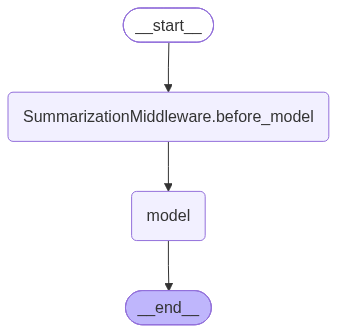

In [3]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

### Message based Summarization
agent = create_agent(
    model = "gpt-5.4-mini",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model = "gpt-5.4-mini",
            trigger=("messages",10),
            keep = ("messages",4)
        )
    ]
)

agent

In [5]:
### Run with thread id
config = {"configurable":{"thread_id":"test_thread_1"}}

#### Summarization Middleware based on length of messages

In [6]:
questions = [
    "What is the capital of India?",
    "What is the population of India?",
    "What is the GDP of India?",
    "What is the literacy rate of India?",
    "What is the life expectancy of India?",
    "What is the main religion of India?",
    "What is the official language of India?"
]

for q in questions:
    response = agent.invoke({"messages" : [HumanMessage(content=q)]}, config=config)
    print(f"Messages : {response}")
    print(f"Messages : {len(response['messages'])}")


Messages : {'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='c2626d07-0f36-4fd0-bd51-1b28a85d2204'), AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 13, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EDnZSYcthgP2xXZPiCn3GyoHHndAb', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a00ef7-dc0e-7823-bce8-35240062ce35-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 13, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_re

In [7]:
response['messages']

[HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\n\nAnswer basic factual questions about India (capital, population, GDP, literacy rate).\n\n## SUMMARY\n\n- The user asked several standalone factual questions about India.\n- Previously answered:\n  - Capital of India: **New Delhi**\n  - Population of India: **about 1.43 billion people** (roughly **1.4 billion**)\n  - GDP of India: **about $3.7 trillion USD nominally**\n- The latest unanswered question is: **What is the literacy rate of India?**\n\n## ARTIFACTS\n\nNone\n\n## NEXT STEPS\n\nProvide the literacy rate of India in response to the user’s last question.', additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='bace5c7c-304c-46d3-8023-725f5f5b905c'),
 AIMessage(content='India’s literacy rate is **about 77%** overall, based on recent estimates.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 124, 'tot

#### Summarization Middleware based on Token size

In [8]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent = create_agent(
    model = "gpt-5.4-mini",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model = "gpt-5.4-mini",
            trigger = ("tokens",200),
            keep = ("tokens",50)
        )
    ]
)

config = {"configurable" : {"thread_id" : "test_thread_2"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token


In [9]:
# Test
cities = ["Singapore", "London", "Chennai", "Madurai", "Paris", "Tokyo", "New York", "Dubai"]

for city in cities:
    response = agent.invoke(
        {
            "messages" : [HumanMessage(content="Find hotels in {city}")]
        },
        config=config
    )

    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Singapore: ~17 tokens, 2 messages
[HumanMessage(content='Find hotels in {city}', additional_kwargs={}, response_metadata={}, id='39149676-1eb2-4478-895f-5982242363dc'), AIMessage(content='Which city would you like me to search hotels in?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 136, 'total_tokens': 150, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EDnbuPbqybyqWvwlz8xqMvayxiyTa', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a00efa-2abd-76e0-9b07-e4790c5c3d50-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 136, 'output_tokens': 14, 'total_tokens': 150, 'input_token_details': {'aud

#### Summarization Middleware based on Fraction

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent = create_agent(
    model = "gpt-5.4-mini",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware = [
        SummarizationMiddleware(
            model = "gpt-5.4-mini",
            trigger = ("fraction",0.005),
            keep = ("fraction",0.002)
        )
    ]
)

config = {"configurable" : {"thread_id" : "test_thread_2"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token


In [11]:
# Test
cities = ["Singapore", "London", "Chennai", "Madurai", "Paris", "Tokyo", "New York", "Dubai"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gpt-4o-mini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Singapore: ~140 tokens (0.1094%), 4 msgs
[HumanMessage(content='Hotels in Singapore', additional_kwargs={}, response_metadata={}, id='90577222-bfb2-42b3-bcff-d47185652959'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 133, 'total_tokens': 151, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EDncaN1uPpOEY4VBixABP0qTpEaT0', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a00efa-d37f-7070-99cb-992fbaeb1f78-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Singapore'}, 'id': 'call_qKRoHwfXw5bvjKszK9naPD5f', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens

#### Human In the Loop MiddleWare

In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [13]:
agent=create_agent(
    model="gpt-5.4-mini",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)

In [14]:
config = {"configurable": {"thread_id": "test_thread_3"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [15]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='2af6a5c9-c235-434b-8735-46d024a8f312'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 178, 'total_tokens': 209, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EDndYK2FyqszOSdzF27Qs79Tgtqze', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a00efb-be2e-7903-99d4-056eeb1a01cc-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'call_EsR8lli5BDEXnhX1hdoe

In [16]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: Done.


In [17]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='2af6a5c9-c235-434b-8735-46d024a8f312'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 178, 'total_tokens': 209, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EDndYK2FyqszOSdzF27Qs79Tgtqze', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a00efb-be2e-7903-99d4-056eeb1a01cc-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@test.com', 'subject': 'Hello', 'body': 'How are you?'}, 'id': 'call_EsR8lli5BDEXnhX1hdoe

##### A working chat bot to extract and send mail

In [ ]:
from langchain.chat_models import init_chat_model
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent=create_agent(
        model="gpt-5.4-mini",
        tools=[read_email_tool,send_email_tool],
        checkpointer=InMemorySaver(),
        middleware=[
            HumanInTheLoopMiddleware(
                interrupt_on={
                    "send_email_tool":{
                        "allowed_decisions":["approve","edit","reject"]
                    },
                    "read_email_tool":False,

                }
            )
        ]
    )

config = {"configurable": {"thread_id": "test_thread_3"}}

while True:
    user_input = input("User :")
    if user_input.lower() in ["quit","close","exit"]:
        break

    # Step 1: Request
    result = agent.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=config
    )

    if "__interrupt__" in result:
        print("⏸️ Paused! Approving...")

        user_decision = input("User (approve/reject):")
        
        result = agent.invoke(
            Command(
                resume={
                    "decisions": [
                        {"type": user_decision}
                    ]
                }
            ),
            config=config
        )
        
        print(f"✅ Result: {result['messages'][-1].content}")
    

⏸️ Paused! Approving...
✅ Result: Done.


: 